In [ ]:
using Pkg
Pkg.activate(normpath(@__DIR__, ".."))

In [8]:
using PyPlot, JLD2, DataFrames, CSV, Statistics

#### Fig 5A

In [5]:
data_dir = "synthetic_data";

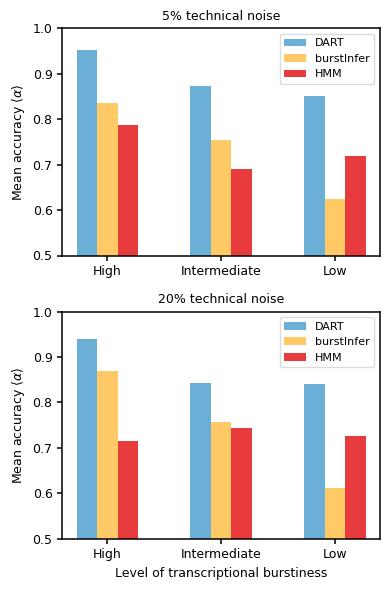

In [15]:
function compute_acc(level::String, traces, cv::Int)
    biaccs, dlaccs, hmmaccs = Float64[], Float64[], Float64[]

    @load joinpath(data_dir,"real_cv$(cv)_data_res/ngen_dl$(level)_compare_seed_1.jld2") rn_met_dl
    @load joinpath(data_dir,"bI_compare_cv$(cv)/gen$(level)_hmm_cv$(cv).jld2") rn_binar_filter rn_met_binar error_ids

    for i in 1:20
        true_trace = traces[i].trace
        idx = traces[i].idx

        base_path = joinpath(data_dir,"bI_compare_cv$(cv)/bI$(level)_acc$(cv)")
        path = if isfile("$base_path/short_cv/gene_$(i)_SINGLE_CELL_POSTERIOR.csv")
            "$base_path/short_cv/gene_$(i)_SINGLE_CELL_POSTERIOR.csv"
        elseif isfile("$base_path/long_cv/gene_$(i)_SINGLE_CELL_POSTERIOR.csv")
            "$base_path/long_cv/gene_$(i)_SINGLE_CELL_POSTERIOR.csv"
        else
            continue
        end

        bi_df = CSV.read(path, DataFrame)
        acc = mean([mean(collect(bi_df[j, :]) .== true_trace[j]) for j in 1:300])
        push!(biaccs, acc)
        push!(dlaccs, rn_met_dl[idx].acc)
    end

    append!(hmmaccs, [x.acc for x in rn_binar_filter])
    return dlaccs, biaccs, hmmaccs
end;

function load_accs(cv::Int)
    @load joinpath(data_dir,"bI_compare_cv$(cv)/genb_traces.jld2") genb_traces
    @load joinpath(data_dir,"bI_compare_cv$(cv)/gennb1_traces.jld2") gennb1_traces
    @load joinpath(data_dir,"bI_compare_cv$(cv)/gennb0_traces.jld2") gennb0_traces
    #@load "synthetic_compare_acc$(cv)/gennb1_traces.jld2" gennb1_traces

    res_b   = mean.(compute_acc("b", genb_traces, cv))
    res_nb1 = mean.(compute_acc("nb1", gennb1_traces, cv))
    res_nb0 = mean.(compute_acc("nb0", gennb0_traces, cv))

    values_dl  = [res_b[1], res_nb1[1], res_nb0[1]]
    values_bi  = [res_b[2], res_nb1[2], res_nb0[2]]
    values_hmm = [res_b[3], res_nb1[3], res_nb0[3]]

    return values_dl, values_bi, values_hmm
end

# ==== Final Plot ====
labels = ["High", "Intermediate", "Low"]
x = 1:length(labels)
width = 0.18
fs = 9

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(4, 6), sharey=true)

# Use actual CV numbers: 0 and 2
cvs = [0, 2]
titles = ["5% technical noise", "20% technical noise"]

for (i, (cv, ax)) in enumerate(zip(cvs, (ax0, ax1)))
    values_dl, values_bi, values_hmm = load_accs(cv)

    ax.bar(x .- width, values_dl, width, label="DART", color="#6baed6")
    ax.bar(x,          values_bi, width, label="burstInfer", color="#ffc966")
    ax.bar(x .+ width, values_hmm, width, label="HMM", color="#e73b3d")

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0.5, 1.0)
    ax.set_title(titles[i], fontsize=fs)
    ax.legend(fontsize=8, frameon=true, facecolor="white", edgecolor="lightgrey") #framealpha=0.5
    ax.set_ylabel(L"Mean accuracy $\langle \alpha \rangle$", fontsize=fs)

    wd = 1.1
    ax.tick_params(axis="both", labelsize=9, width=wd)
    for spine in values(ax.spines)
        spine.set_linewidth(wd)
    end
end

ax1.set_xlabel("Level of transcriptional burstiness", fontsize=fs)

plt.tight_layout()
fig.savefig("figs/DL_noise_compare.pdf", bbox_inches="tight");

#### Fig 5B

In [13]:
# example burstinfer trace
@load joinpath(data_dir,"real_cv0_data_res/ngen_dlnb0_compare_seed_1.jld2") rn_met_dl
dl_res = copy(rn_met_dl)

csv_dir = joinpath(data_dir,"bI_compare_cv0/bInb0_acc0/short_cv/gene_1_SINGLE_CELL_POSTERIOR.csv")
bi_res = CSV.read(csv_dir, DataFrame);

# example DART trace
@load joinpath(data_dir, "bI_compare_cv0/dl_eg_traces.jld2") dl_eg_trace;

#example true (SSA) trace
@load joinpath(data_dir, "bI_compare_cv0/gennb0_traces.jld2") gennb0_traces;

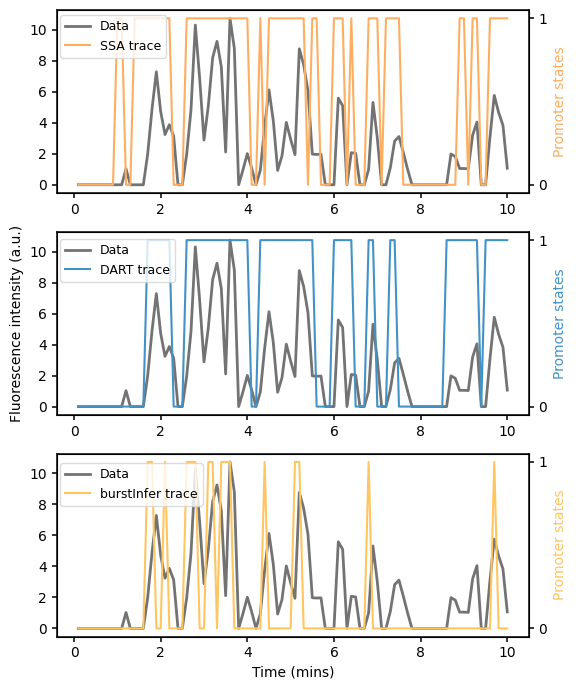

In [14]:
fig, axes = subplots(3, 1, figsize=(6, 7))
fs = 10
wd = 1.1

# Setup
trace_id = 1
cell_id = 14
t_int = 1:100
x = 0.1 .* (1:length(t_int))
y1 = gennb0_traces[trace_id].nsyn[cell_id][t_int]  # shared data

# Each subplot's promoter trace and color
promoter_traces = [gennb0_traces[trace_id].trace[cell_id][t_int],  # SSA
                   dl_eg_trace[t_int],  # DART
                   collect(bi_res[cell_id, :][t_int])]             # burstInfer

labels = ["SSA trace", "DART trace", "burstInfer trace"]
colors = ["#fdae61", "#4292c6", "#ffc560"] #"#ffc960"

for i in 1:3
    ax = axes[i, 1]
    ax_twin = ax.twinx()

    # Plot data
    line1, = ax.plot(x, y1, color="#737373", label="Data", lw=2)
    line2, = ax_twin.plot(x, promoter_traces[i], color=colors[i], label=labels[i], lw=1.5)

    # Y-axis label for twin
    ax_twin.set_ylabel("Promoter states", fontsize=fs, color=colors[i])
    ax_twin.set_ylim(-0.05, 1.05)
    ax_twin.set_yticks([0.0, 1.0])

    # Styling
    ax.tick_params(axis="both", labelsize=10, width=wd)
    ax_twin.tick_params(axis="both", labelsize=10, width=wd)
    for spine in values(ax.spines)
        spine.set_linewidth(wd)
    end

    # Set labels
    if i == 2
        ax.set_ylabel("Fluorescence intensity (a.u.)", fontsize=fs)
    elseif i == 3
        ax.set_xlabel("Time (mins)", fontsize=fs)
    end

    # Legend
    lines = [line1, line2]
    leg_labels = [line.get_label() for line in lines]
    leg = fig.legend(lines, leg_labels, loc="upper left",
                     bbox_to_anchor=(0.12, 0.98 - 0.32 * (i - 1)),
                     fontsize=9, frameon=true,
                     facecolor="white", edgecolor="lightgrey")
    leg.set_zorder(999)
end

tight_layout()
savefig("figs/DL_compare_eg.pdf", bbox_inches="tight")
